In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# GPU Memory Growth Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)
        
from config import Config
from scene_engine import setup_scene
from channel_analyzer import compute_batch_paths, get_ofdm_channel, compute_spatial_covariance
from dataset_exporter import save_dataset


2026-07-28 01:32:40.326924: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Memory Growth Enabled


jitc_llvm_init(): LLVM API initialization failed ..


In [ ]:
config = Config()
scene, bs, ue, pos_tensor = setup_scene(config)
print("Trajectory shape:", pos_tensor.shape)

Trajectory shape: (50, 3)


I0000 00:00:1785202363.527020  803612 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46168 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1785202363.530172  803612 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43585 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1785202363.531635  803612 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46548 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9


In [ ]:
paths = compute_batch_paths(scene, max_depth=3)
h_tensor = get_ofdm_channel(paths, config)
print("H tensor shape (N_pos, N_sub, N_tx):", h_tensor.shape)
scene.preview(paths=paths)

H tensor shape (N_pos, N_sub, N_tx): (50, 600, 64)


In [ ]:
R_matrix = compute_spatial_covariance(h_tensor)
print("Spatial Covariance Matrix shape (N_sub, N_tx, N_tx):", R_matrix.shape)
# Average across subcarriers for visualization
R_avg = tf.reduce_mean(R_matrix, axis=0)
print("Averaged R shape:", R_avg.shape)


Spatial Covariance Matrix shape (N_sub, N_tx, N_tx): (600, 64, 64)
Averaged R shape: (64, 64)


In [ ]:
# Cell 4: Train GMM and do MAP inference
from GMM.main import gmm_em_fit_fullcov, predict_modes
import torch

# Extract spatial CSI for the center subcarrier to avoid OOM
# h_tensor shape: (N_pos, N_sub, N_tx)
h_spatial = h_tensor[:, 300, :] # Shape: (50, 64) complex

# Convert complex to real by concatenating real and imaginary parts
h_real_tf = tf.concat([tf.math.real(h_spatial), tf.math.imag(h_spatial)], axis=-1) # Shape: (50, 128)

# Convert to PyTorch tensor for the GMM module
h_real = torch.from_numpy(h_real_tf.numpy()).to(torch.float32)

print("Training GMM on the spatial CSI vectors...")
# Fit GMM using EM
K = 3 # Number of clusters
params_em = gmm_em_fit_fullcov(h_real, K=K, num_iter=50, eps=1e-6, seed=42, verbose=True)

# MAP state inference
c_hat, logp = predict_modes(h_real, params_em, return_logp=True)

print("MAP States for the trajectory:")
print(c_hat.numpy())


Training GMM on the spatial CSI vectors...
[EM] it=000 ll=26778.971
[EM] it=001 ll=28237.605 dLL=1458.635
[EM] it=002 ll=29727.186 dLL=1489.580
[EM] it=003 ll=30174.994 dLL=447.809
[EM] it=004 ll=30172.357 dLL=-2.637
[EM] it=005 ll=30172.357 dLL=0.000
[EM] it=006 ll=30172.357 dLL=0.000
[EM] it=007 ll=30172.357 dLL=0.000
[EM] it=008 ll=30172.357 dLL=0.000
[EM] it=009 ll=30172.357 dLL=0.000
[EM] it=010 ll=30172.357 dLL=0.000
[EM] it=011 ll=30172.357 dLL=0.000
[EM] it=012 ll=30172.357 dLL=0.000
[EM] it=013 ll=30172.357 dLL=0.000
[EM] it=014 ll=30172.357 dLL=0.000
[EM] it=015 ll=30172.357 dLL=0.000
[EM] it=016 ll=30172.357 dLL=0.000
[EM] it=017 ll=30172.357 dLL=0.000
[EM] it=018 ll=30172.357 dLL=0.000
[EM] it=019 ll=30172.357 dLL=0.000
[EM] it=020 ll=30172.357 dLL=0.000
[EM] it=021 ll=30172.357 dLL=0.000
[EM] it=022 ll=30172.357 dLL=0.000
[EM] it=023 ll=30172.357 dLL=0.000
[EM] it=024 ll=30172.357 dLL=0.000
[EM] it=025 ll=30172.357 dLL=0.000
[EM] it=026 ll=30172.357 dLL=0.000
[EM] it=027 l

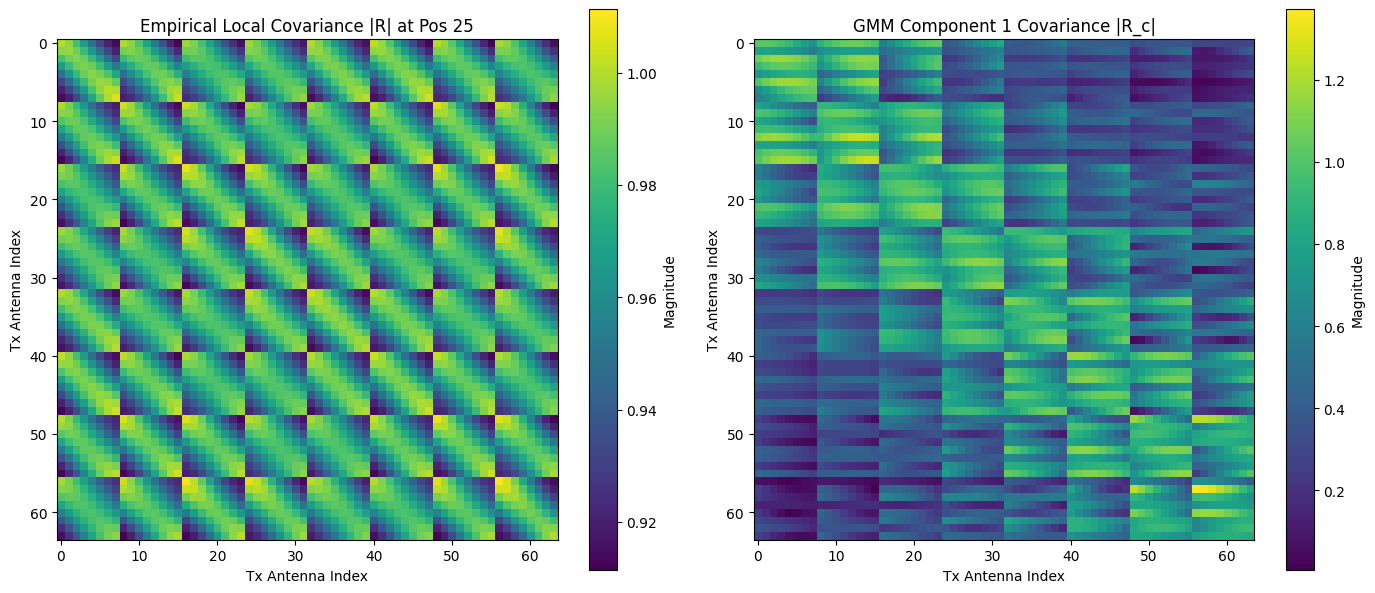

Saved dataset to data


In [ ]:
# Cell 5: Visualization of Covariance Matrix Transitions and Comparison

def reconstruct_complex_cov(R_real):
    # R_real is 2N_t x 2N_t
    N_t = R_real.shape[0] // 2
    R_xx = R_real[:N_t, :N_t]
    R_xy = R_real[:N_t, N_t:]
    return 2 * (R_xx - 1j * R_xy)

# We plot the empirical covariance for a selected point and compare it with the GMM component
selected_pos = 25
c_sel = c_hat[selected_pos].item()

h_exp = tf.expand_dims(h_tensor, axis=-1)
R_per_pos = tf.matmul(h_exp, h_exp, adjoint_b=True)
R_local_emp = tf.reduce_mean(R_per_pos[selected_pos], axis=0)

# Reconstruct complex covariance for the selected state
U_c = params_em.U[c_sel].numpy()
lam_c = params_em.lam[c_sel].numpy()
R_c_real = U_c @ np.diag(lam_c) @ U_c.T
R_c_complex = reconstruct_complex_cov(R_c_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(np.abs(R_local_emp.numpy()), cmap="viridis")
axes[0].set_title(f"Empirical Local Covariance |R| at Pos {selected_pos}")
axes[0].set_xlabel("Tx Antenna Index")
axes[0].set_ylabel("Tx Antenna Index")
fig.colorbar(im0, ax=axes[0], label="Magnitude")

im1 = axes[1].imshow(np.abs(R_c_complex), cmap="viridis")
axes[1].set_title(f"GMM Component {c_sel} Covariance |R_c|")
axes[1].set_xlabel("Tx Antenna Index")
axes[1].set_ylabel("Tx Antenna Index")
fig.colorbar(im1, ax=axes[1], label="Magnitude")

plt.tight_layout()
plt.show()

# Export data
save_dataset(h_tensor, R_matrix)


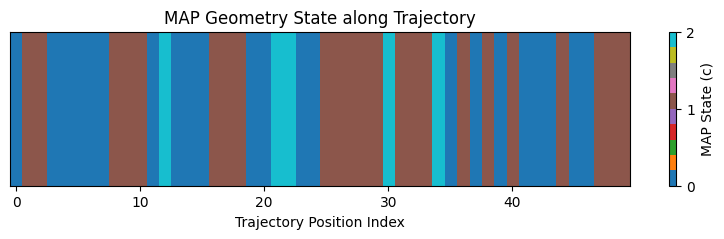

In [ ]:
# Cell 6: Visualization of MAP state transitions along trajectory
plt.figure(figsize=(10, 2))
plt.imshow(c_hat.numpy()[None, :], cmap='tab10', aspect='auto')
plt.colorbar(ticks=range(K), label='MAP State (c)')
plt.title('MAP Geometry State along Trajectory')
plt.xlabel('Trajectory Position Index')
plt.yticks([])
plt.show()


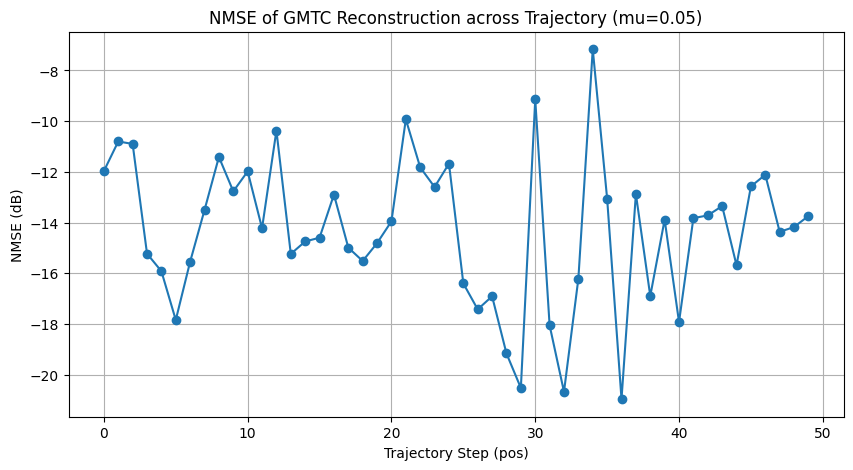

Average NMSE (dB): -14.32


In [ ]:
# Cell 7: GMTC Compression, Reconstruction, and NMSE Evaluation
import numpy as np

# 1. Reconstruct complex covariances for all K states and perform eigendecomposition
K = params_em.pi.shape[0]
U_c_complex_list = []
lam_c_complex_list = []

for c in range(K):
    U_c_real = params_em.U[c].numpy()
    lam_c_real = params_em.lam[c].numpy()
    R_c_real = U_c_real @ np.diag(lam_c_real) @ U_c_real.T
    # Use the reconstruct_complex_cov from Cell 5
    R_c_comp = reconstruct_complex_cov(R_c_real)
    
    # Eigendecomposition
    evals, evecs = np.linalg.eigh(R_c_comp)
    # Sort in descending order
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    lam_c_complex_list.append(evals)
    U_c_complex_list.append(evecs)

# Prepare arrays for GMTC simulation
h_spatial_np = h_spatial.numpy() # Shape: (50, 64) complex
N_pos = h_spatial_np.shape[0]
h_hat = np.zeros_like(h_spatial_np)

# 2. Multi-Modal Reverse-Waterfilling Simulation
mu = 0.05 # Tunable water-level parameter

for t in range(N_pos):
    c_hat_t = c_hat[t].item()
    h_t = h_spatial_np[t]
    
    U_c = U_c_complex_list[c_hat_t]
    lam_c = lam_c_complex_list[c_hat_t]
    
    # Component-Matched KLT (Transform)
    h_tilde = U_c.conj().T @ h_t
    
    # Truncation via reverse-waterfilling
    mask = lam_c > mu
    h_tilde_q = h_tilde * mask
    
    # Inverse KLT (Reconstruction)
    h_hat[t] = U_c @ h_tilde_q

# 3. NMSE Calculation
nmse_linear = np.sum(np.abs(h_spatial_np - h_hat)**2, axis=1) / np.sum(np.abs(h_spatial_np)**2, axis=1)
nmse_db = 10 * np.log10(nmse_linear + 1e-12) # added epsilon for numerical stability

# 4. Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(N_pos), nmse_db, marker="o", linestyle="-")
plt.title(f"NMSE of GMTC Reconstruction across Trajectory (mu={mu})")
plt.xlabel("Trajectory Step (pos)")
plt.ylabel("NMSE (dB)")
plt.grid(True)
plt.show()

print(f"Average NMSE (dB): {np.mean(nmse_db):.2f}")
